BoW

In [30]:
import pandas as pd

df = pd.read_csv("WELFake_clean.csv")
df = df.dropna(subset=['text', 'label'])

In [31]:
X_text = df['text']
y = df['label']

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [35]:
from collections import Counter
from scipy.sparse import lil_matrix

# 1. Vocabulario con las 5000 palabras más frecuentes
contador = Counter()
for doc in X_train:
    contador.update(doc.split())

vocab = sorted([word for word, _ in contador.most_common(5000)])
word2idx = {word: i for i, word in enumerate(vocab)}
print(f"Vocabulario: {len(vocab)} palabras")

# 2. Construir matriz BoW
def build_bow_matrix(corpus, word2idx):
    matrix = lil_matrix((len(corpus), len(word2idx)))
    for i, doc in enumerate(corpus):
        for word in doc.split():
            if word in word2idx:
                matrix[i, word2idx[word]] += 1
    return matrix.tocsr()

print("Construyendo X_train_bow...")
X_train_bow = build_bow_matrix(list(X_train), word2idx)

print("Construyendo X_test_bow...")
X_test_bow = build_bow_matrix(list(X_test), word2idx)

print(f"✅ BoW listo — Shape: {X_train_bow.shape}")

Vocabulario: 5000 palabras
Construyendo X_train_bow...
Construyendo X_test_bow...
✅ BoW listo — Shape: (50488, 5000)


BoW vs TF-IDF

In [34]:
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from scipy.sparse import lil_matrix

# ── BoW manual con set ───────────────────────────────────────────────────
# 1. Vocabulario con las 5000 palabras más frecuentes
contador = Counter()
for doc in X_train:
    contador.update(doc.split())

vocab = sorted([word for word, _ in contador.most_common(5000)])
word2idx = {word: i for i, word in enumerate(vocab)}
print(f"Vocabulario: {len(vocab)} palabras")

# 2. Convertir a matriz BoW (sparse para no explotar RAM)
def build_bow_matrix(corpus, word2idx):
    matrix = lil_matrix((len(corpus), len(word2idx)))
    for i, doc in enumerate(corpus):
        for word in doc.split():
            if word in word2idx:
                matrix[i, word2idx[word]] += 1
    return matrix.tocsr()

print("Construyendo X_train_bow...")
X_train_bow = build_bow_matrix(list(X_train), word2idx)

print("Construyendo X_test_bow...")
X_test_bow = build_bow_matrix(list(X_test), word2idx)

print(f"✅ BoW listo — Shape: {X_train_bow.shape}")

# ── TF-IDF con sklearn ───────────────────────────────────────────────────
tfidf = TfidfVectorizer(stop_words='english', max_features=5000, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"✅ TF-IDF listo — Shape: {X_train_tfidf.shape}")

Vocabulario: 5000 palabras
Construyendo X_train_bow...
Construyendo X_test_bow...
✅ BoW listo — Shape: (50488, 5000)
✅ TF-IDF listo — Shape: (50488, 5000)


Se implementó manualmente la técnica Bag of Words utilizando estructuras básicas de Python como conjuntos (set) para construir el vocabulario. Esta implementación permite comprender cómo se representa el texto como vectores numéricos. Sin embargo, debido a su costo computacional, para el modelo final se utilizó CountVectorizer.

Baseline de los modelos 

In [36]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import pandas as pd

modelos = {
    "Naive Bayes":         MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM":                 LinearSVC(max_iter=1000),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
}

representaciones = {
    "TF-IDF": (X_train_tfidf, X_test_tfidf),
    "BoW":    (X_train_bow,   X_test_bow),
}

resumen = []

for rep_nombre, (X_tr, X_te) in representaciones.items():
    for modelo_nombre, modelo in modelos.items():
        print(f"▶ {modelo_nombre} | {rep_nombre}")
        
        modelo.fit(X_tr, y_train)
        y_pred = modelo.predict(X_te)
        
        r = classification_report(y_test, y_pred,
                                  target_names=["Real", "Fake"],
                                  output_dict=True)
        resumen.append({
            "Modelo":   modelo_nombre,
            "Repr":     rep_nombre,
            "Accuracy": round(r["accuracy"], 4),
            "F1 Macro": round(r["macro avg"]["f1-score"], 4),
            "F1 Real":  round(r["Real"]["f1-score"], 4),
            "F1 Fake":  round(r["Fake"]["f1-score"], 4),
        })
        print(f"  ✅ Accuracy: {r['accuracy']:.4f} | F1 Macro: {r['macro avg']['f1-score']:.4f}")

# Resumen final
df_baseline = pd.DataFrame(resumen)
print("\n", df_baseline.to_string(index=False))
df_baseline.to_csv("baseline_resultados.csv", index=False)
print("\n✅ Guardado en baseline_resultados.csv")

▶ Naive Bayes | TF-IDF
  ✅ Accuracy: 0.8354 | F1 Macro: 0.8341
▶ Logistic Regression | TF-IDF
  ✅ Accuracy: 0.9420 | F1 Macro: 0.9414
▶ SVM | TF-IDF
  ✅ Accuracy: 0.9432 | F1 Macro: 0.9426
▶ Decision Tree | TF-IDF
  ✅ Accuracy: 0.8896 | F1 Macro: 0.8884
▶ Naive Bayes | BoW
  ✅ Accuracy: 0.9163 | F1 Macro: 0.9152
▶ Logistic Regression | BoW
  ✅ Accuracy: 0.9748 | F1 Macro: 0.9746
▶ SVM | BoW


/Users/itzelflores/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  ✅ Accuracy: 0.9715 | F1 Macro: 0.9712
▶ Decision Tree | BoW
  ✅ Accuracy: 0.9678 | F1 Macro: 0.9675

              Modelo   Repr  Accuracy  F1 Macro  F1 Real  F1 Fake
        Naive Bayes TF-IDF    0.8354    0.8341   0.8490   0.8192
Logistic Regression TF-IDF    0.9420    0.9414   0.9474   0.9354
                SVM TF-IDF    0.9432    0.9426   0.9484   0.9369
      Decision Tree TF-IDF    0.8896    0.8884   0.8997   0.8772
        Naive Bayes    BoW    0.9163    0.9152   0.9248   0.9056
Logistic Regression    BoW    0.9748    0.9746   0.9771   0.9721
                SVM    BoW    0.9715    0.9712   0.9741   0.9683
      Decision Tree    BoW    0.9678    0.9675   0.9708   0.9643

✅ Guardado en baseline_resultados.csv


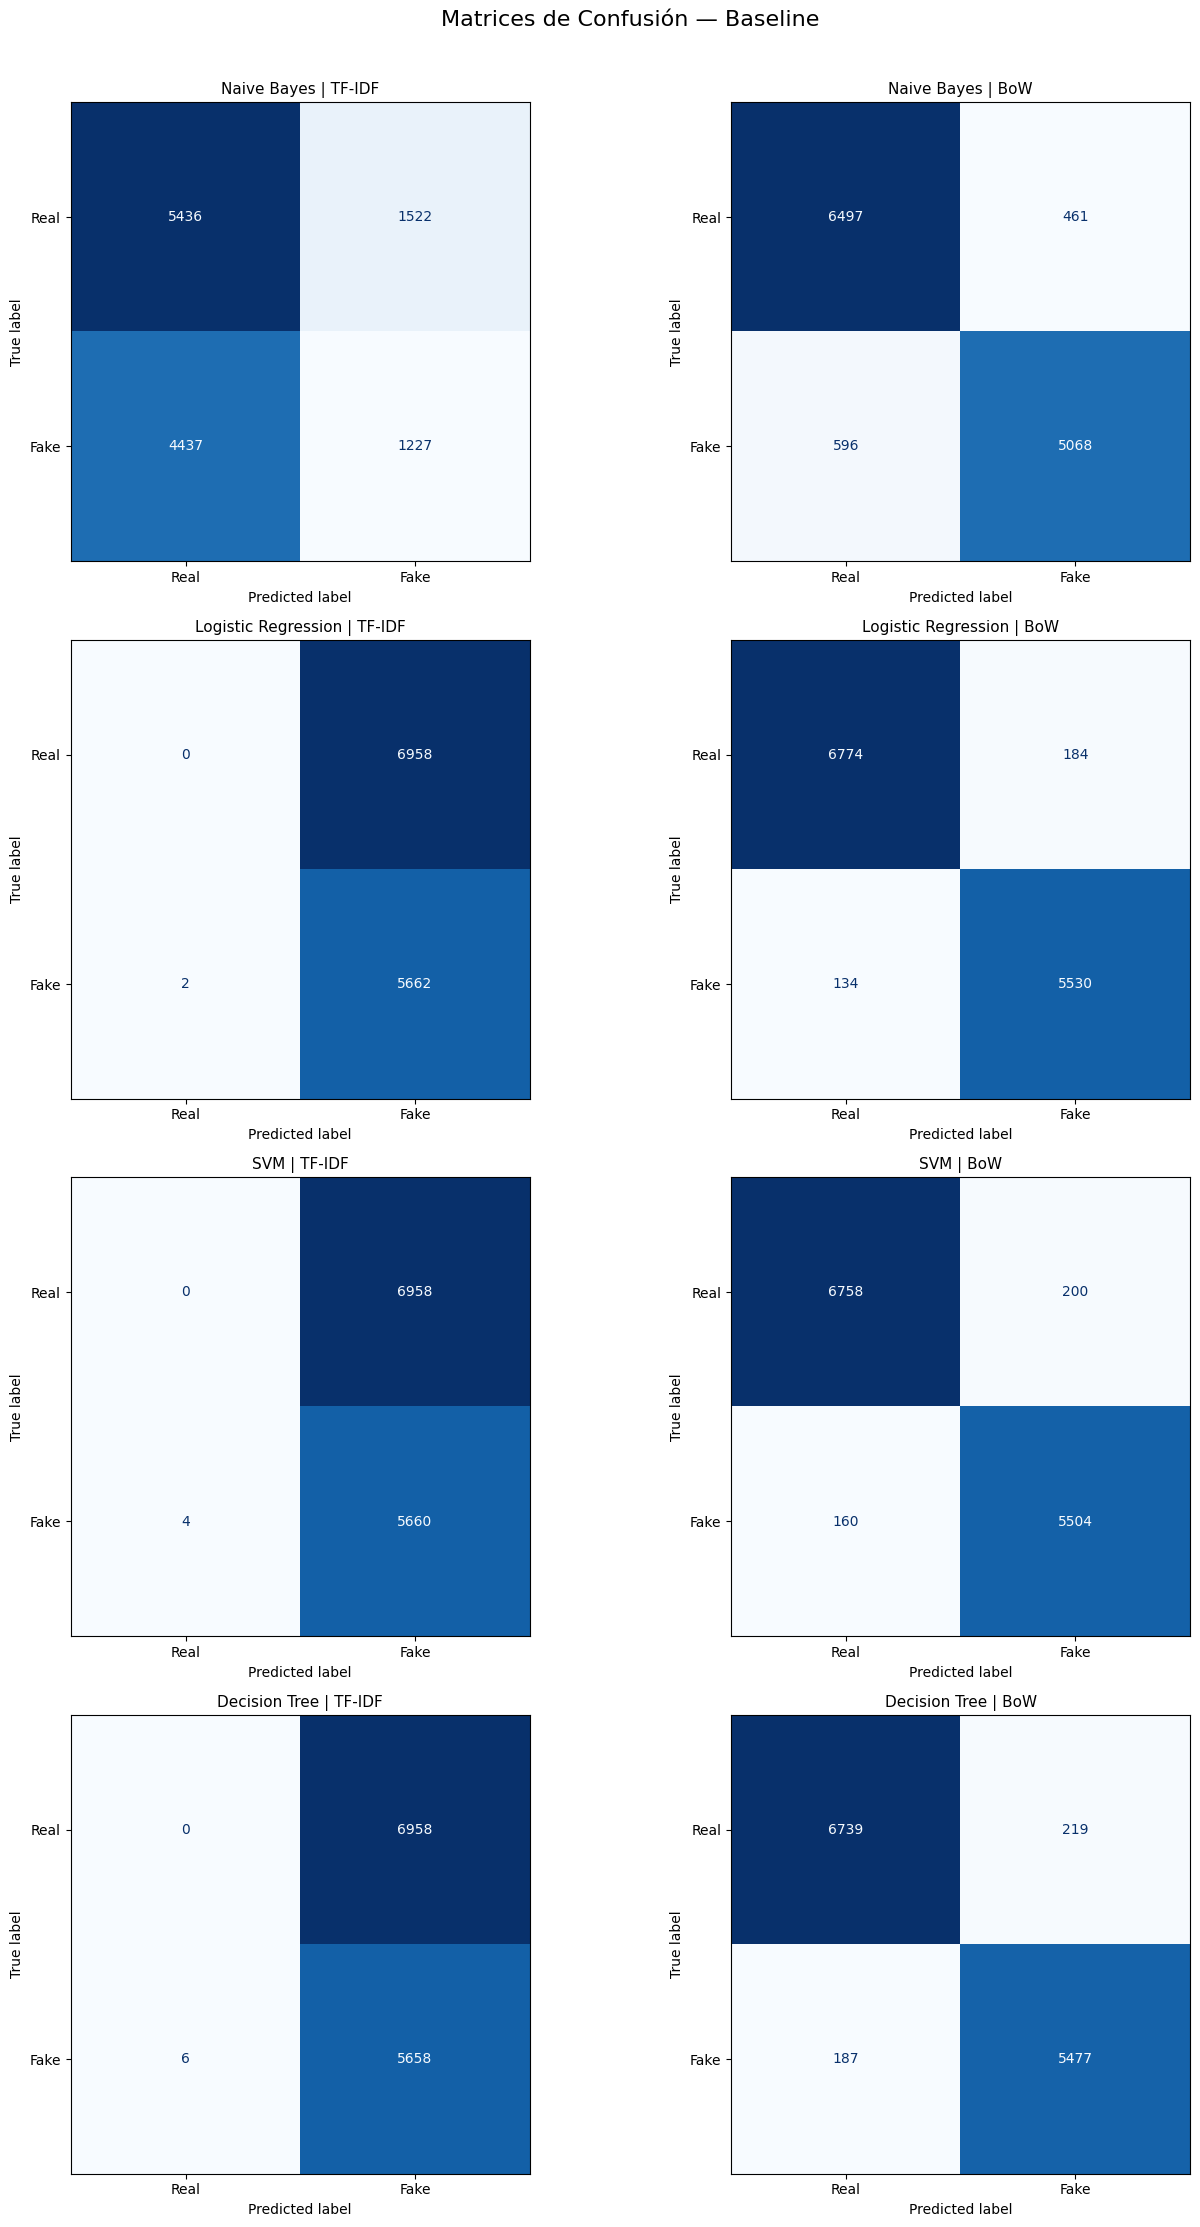

✅ Guardado en confusion_matrices_baseline.png


In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(4, 2, figsize=(14, 22))
fig.suptitle("Matrices de Confusión — Baseline", fontsize=16, y=1.01)

for rep_nombre, (X_tr, X_te) in representaciones.items():
    for idx, (modelo_nombre, modelo) in enumerate(modelos.items()):
        
        col = 0 if rep_nombre == "TF-IDF" else 1
        ax = axes[idx][col]
        
        y_pred = modelo.predict(X_te)
        cm = confusion_matrix(y_test, y_pred)
        
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=["Real", "Fake"])
        disp.plot(cmap="Blues", ax=ax, colorbar=False)
        ax.set_title(f"{modelo_nombre} | {rep_nombre}", fontsize=11)

plt.tight_layout()
plt.savefig("confusion_matrices_baseline.png", dpi=150)
plt.show()
print("✅ Guardado en confusion_matrices_baseline.png")

RandomizedSearchCV

In [38]:
from sklearn.model_selection import RandomizedSearchCV
import time

param_nb = {
    "alpha": [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 3.0]
}

param_lr = {
    "C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    "max_iter": [500, 1000]
}

param_svm = {
    "C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    "max_iter": [1000, 2000]
}

param_dt = {
    "max_depth": [5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}

configs = [
    ("Naive Bayes",         MultinomialNB(),          param_nb),
    ("Logistic Regression", LogisticRegression(),     param_lr),
    ("SVM",                 LinearSVC(),              param_svm),
    ("Decision Tree",       DecisionTreeClassifier(random_state=42), param_dt),
]

representaciones_tuned = {
    "TF-IDF": (X_train_tfidf, X_test_tfidf),
    "BoW":    (X_train_bow,   X_test_bow),
}

resultados_tuned = {}
resumen_tuned = []

for rep_nombre, (X_tr, X_te) in representaciones_tuned.items():
    for modelo_nombre, modelo, params in configs:
        print(f"\n{'='*50}")
        print(f"▶ {modelo_nombre} | {rep_nombre}")
        print(f"{'='*50}")

        inicio = time.time()

        search = RandomizedSearchCV(
            modelo,
            param_distributions=params,
            n_iter=30,
            cv=2,
            scoring='f1',
            random_state=42,
            n_jobs=1
        )
        search.fit(X_tr, y_train)

        tiempo = time.time() - inicio
        resultados_tuned[(modelo_nombre, rep_nombre)] = (search, X_te)

        # Guardado parcial
        pd.DataFrame(search.cv_results_).to_csv(
            f"tuned_{modelo_nombre.replace(' ','_').lower()}_{rep_nombre.lower()}.csv",
            index=False
        )

        y_pred = search.predict(X_te)
        r = classification_report(y_test, y_pred,
                                  target_names=["Real", "Fake"],
                                  output_dict=True)
        resumen_tuned.append({
            "Modelo":   modelo_nombre,
            "Repr":     rep_nombre,
            "Accuracy": round(r["accuracy"], 4),
            "F1 Macro": round(r["macro avg"]["f1-score"], 4),
            "F1 Real":  round(r["Real"]["f1-score"], 4),
            "F1 Fake":  round(r["Fake"]["f1-score"], 4),
            "Mejor CV": round(search.best_score_, 4),
            "Params":   search.best_params_
        })

        print(f"  ✅ {tiempo/60:.1f} min | CV F1: {search.best_score_:.4f}")
        print(f"  Params: {search.best_params_}")

# Resumen final
df_tuned = pd.DataFrame(resumen_tuned)
print("\n", df_tuned.to_string(index=False))
df_tuned.to_csv("tuned_resultados.csv", index=False)
print("\n✅ Guardado en tuned_resultados.csv")


▶ Naive Bayes | TF-IDF


/Users/itzelflores/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=30. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  ✅ 0.0 min | CV F1: 0.8308
  Params: {'alpha': 0.01}

▶ Logistic Regression | TF-IDF


/Users/itzelflores/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=30. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  ✅ 0.0 min | CV F1: 0.9379
  Params: {'max_iter': 500, 'C': 10.0}

▶ SVM | TF-IDF


...

  ✅ 0.0 min | CV F1: 0.9142
  Params: {'alpha': 0.01}

▶ Logistic Regression | BoW


/Users/itzelflores/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=30. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  ✅ 0.9 min | CV F1: 0.9725
  Params: {'max_iter': 500, 'C': 0.1}

▶ SVM | BoW


/Users/itzelflores/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=30. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/Users/itzelflores/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/itzelflores/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  ✅ 2.2 min | CV F1: 0.9721
  Params: {'max_iter': 1000, 'C': 0.01}

▶ Decision Tree | BoW
  ✅ 1.4 min | CV F1: 0.9618
  Params: {'min_samples_split': 20, 'min_samples_leaf': 5, 'max_depth': 20, 'criterion': 'gini'}

              Modelo   Repr  Accuracy  F1 Macro  F1 Real  F1 Fake  Mejor CV                                                                                   Params
        Naive Bayes TF-IDF    0.8364    0.8351   0.8499   0.8203    0.8308                                                                          {'alpha': 0.01}
Logistic Regression TF-IDF    0.9447    0.9441   0.9498   0.9385    0.9379                                                             {'max_iter': 500, 'C': 10.0}
                SVM TF-IDF    0.9440    0.9434   0.9490   0.9378    0.9348                                                             {'max_iter': 1000, 'C': 0.1}
      Decision Tree TF-IDF    0.8884    0.8875   0.8972   0.8778    0.8874 {'min_samples_split': 2, 'min_samples_leaf': 2, 'ma

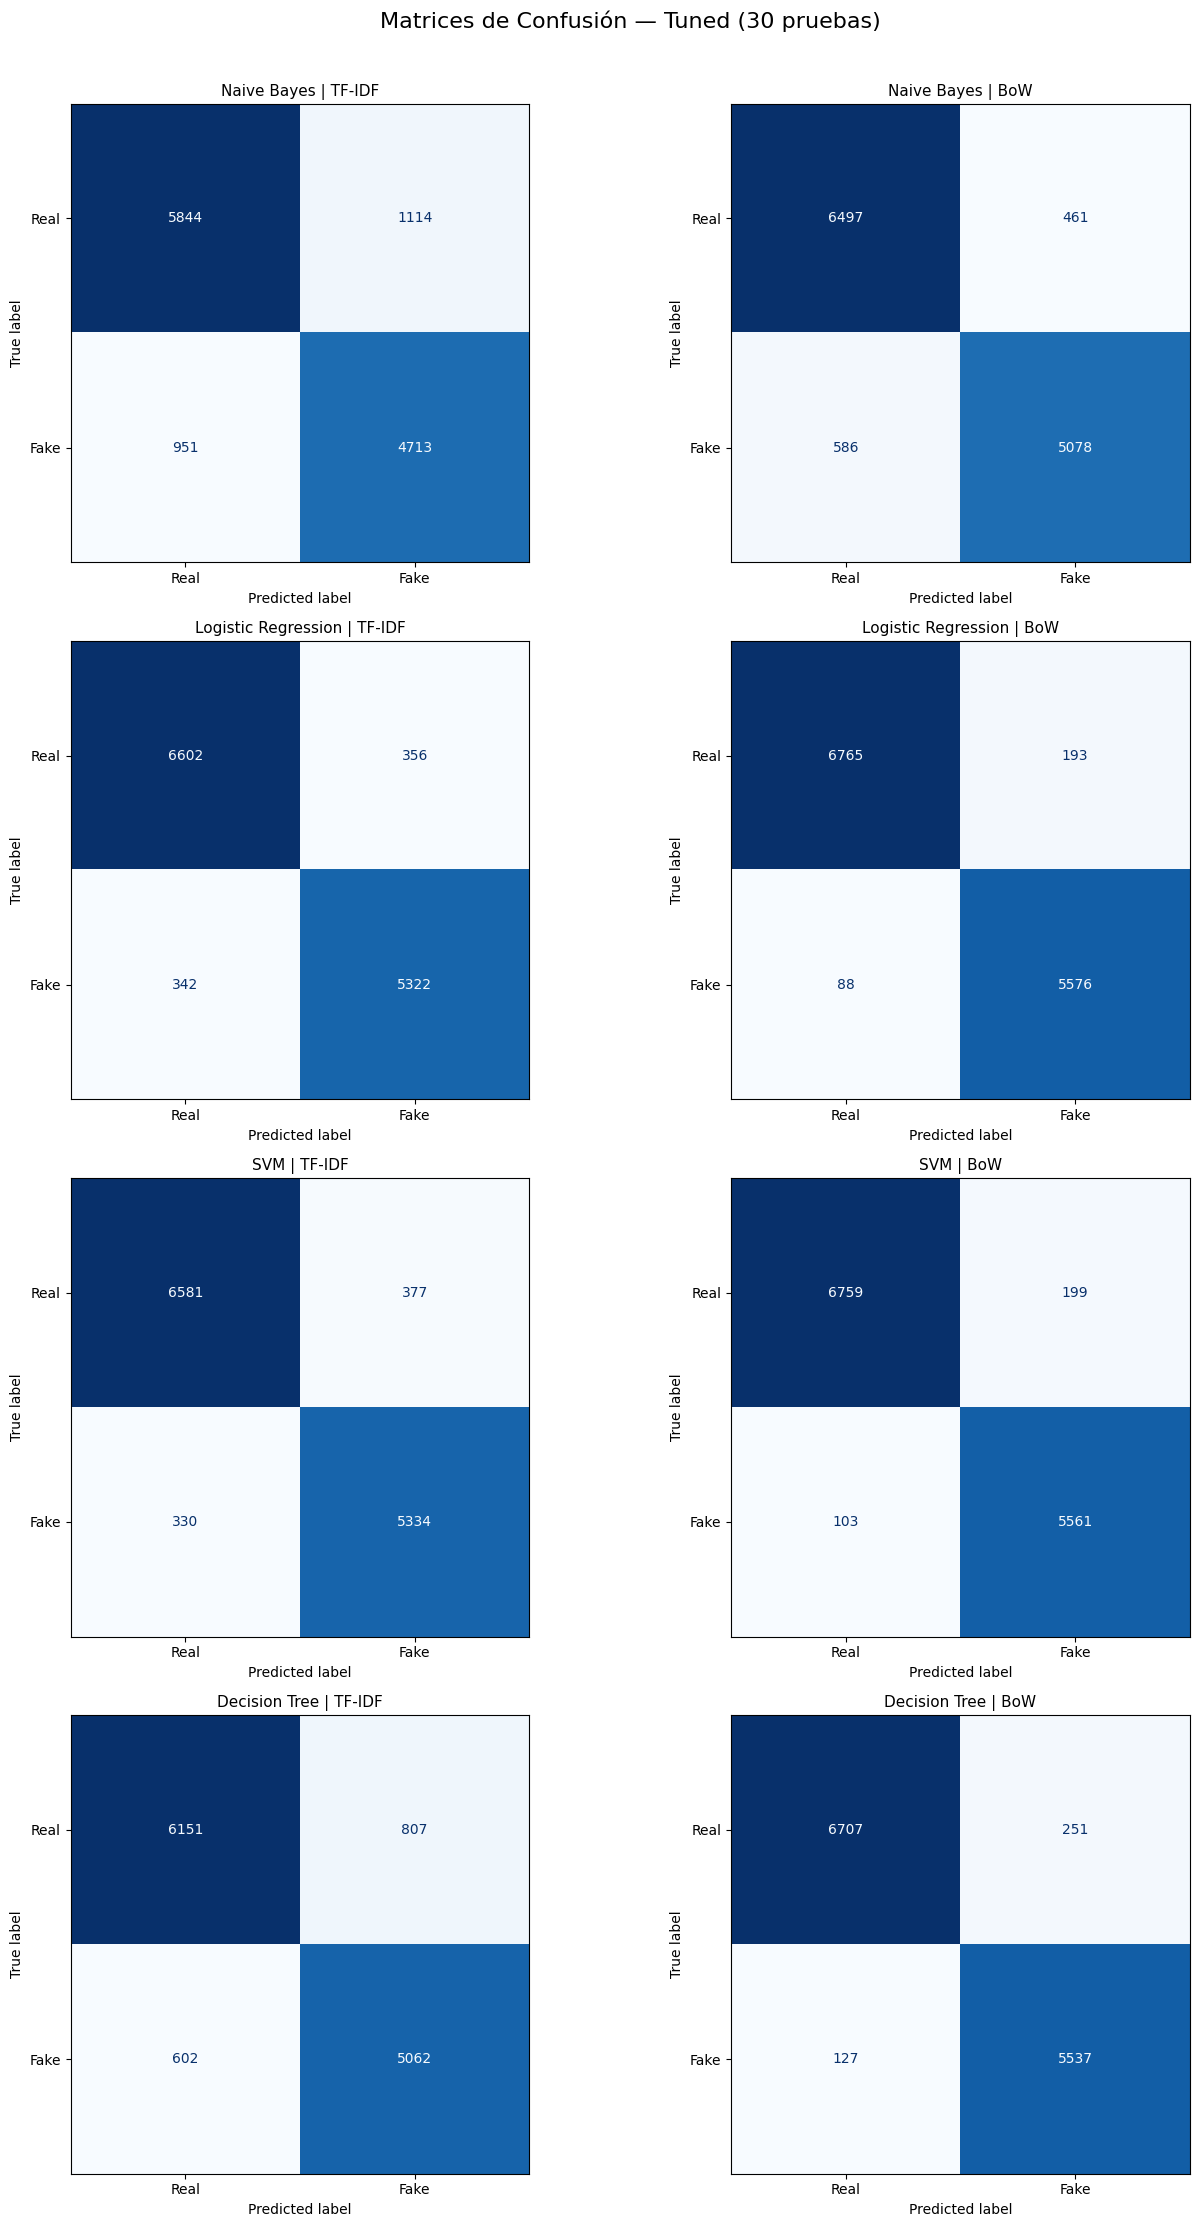

✅ Guardado en confusion_matrices_tuned.png


In [39]:
fig, axes = plt.subplots(4, 2, figsize=(14, 22))
fig.suptitle("Matrices de Confusión — Tuned (30 pruebas)", fontsize=16, y=1.01)

for rep_nombre, (X_tr, X_te) in representaciones_tuned.items():
    for idx, (modelo_nombre, modelo, _) in enumerate(configs):
        col = 0 if rep_nombre == "TF-IDF" else 1
        ax = axes[idx][col]

        search, X_te = resultados_tuned[(modelo_nombre, rep_nombre)]
        y_pred = search.predict(X_te)
        cm = confusion_matrix(y_test, y_pred)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=["Real", "Fake"])
        disp.plot(cmap="Blues", ax=ax, colorbar=False)
        ax.set_title(f"{modelo_nombre} | {rep_nombre}", fontsize=11)

plt.tight_layout()
plt.savefig("confusion_matrices_tuned.png", dpi=150)
plt.show()
print("✅ Guardado en confusion_matrices_tuned.png")

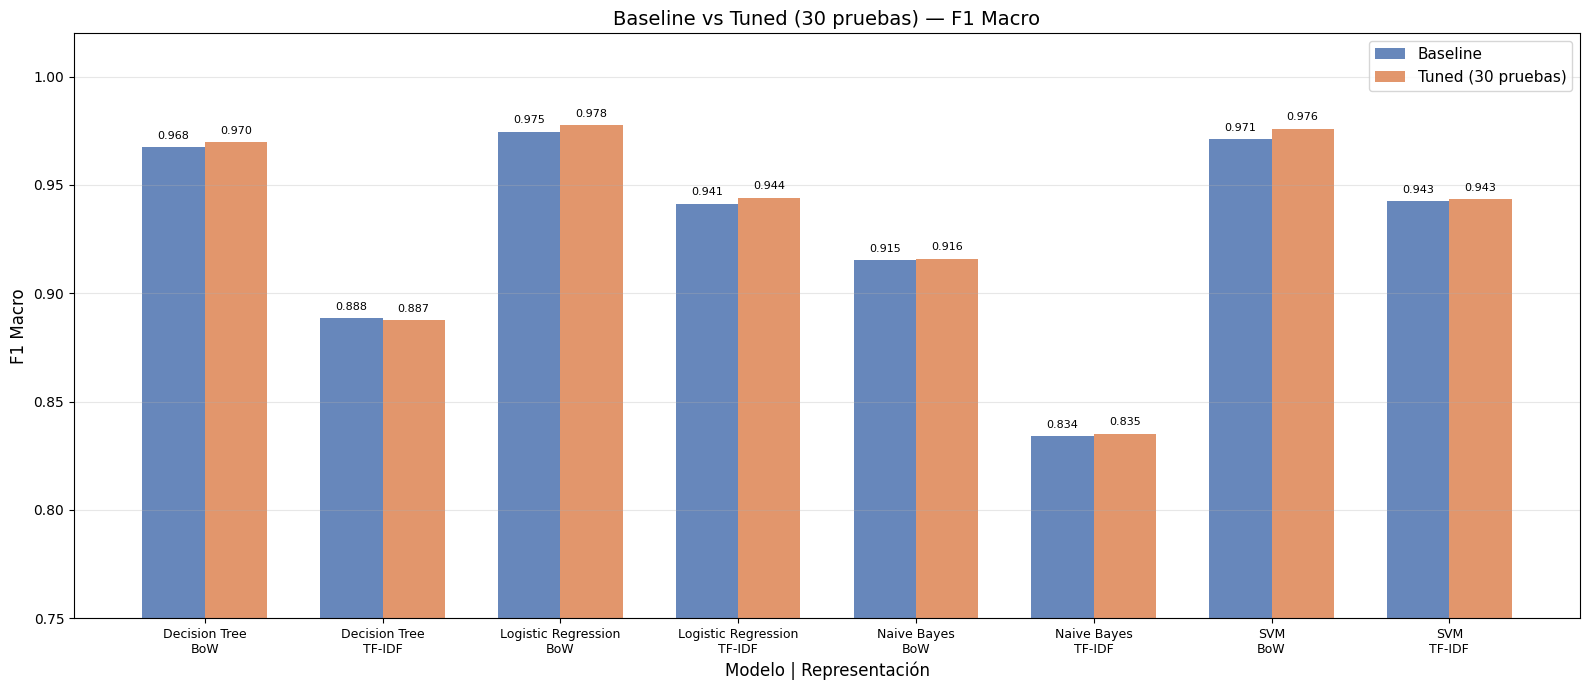

✅ Guardado en comparacion_baseline_vs_tuned.png


In [40]:
import matplotlib.pyplot as plt
import numpy as np

# ── Datos baseline (del df_baseline que ya tienes) ──────────────────────
baseline = df_baseline.copy()
baseline["Label"] = baseline["Modelo"] + "\n" + baseline["Repr"]

# ── Datos tuned (del df_tuned que ya tienes) ────────────────────────────
tuned = df_tuned.copy()
tuned["Label"] = tuned["Modelo"] + "\n" + tuned["Repr"]

# ── Ordenar igual para que coincidan ────────────────────────────────────
baseline = baseline.sort_values(["Modelo", "Repr"]).reset_index(drop=True)
tuned     = tuned.sort_values(["Modelo", "Repr"]).reset_index(drop=True)

labels   = baseline["Label"].tolist()
f1_base  = baseline["F1 Macro"].tolist()
f1_tuned = tuned["F1 Macro"].tolist()

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 7))

bars1 = ax.bar(x - width/2, f1_base,  width, label="Baseline", color="#4C72B0", alpha=0.85)
bars2 = ax.bar(x + width/2, f1_tuned, width, label="Tuned (30 pruebas)", color="#DD8452", alpha=0.85)

# Etiquetas encima de cada barra
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Modelo | Representación", fontsize=12)
ax.set_ylabel("F1 Macro", fontsize=12)
ax.set_title("Baseline vs Tuned (30 pruebas) — F1 Macro", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0.75, 1.02)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("comparacion_baseline_vs_tuned.png", dpi=150)
plt.show()
print("✅ Guardado en comparacion_baseline_vs_tuned.png")